# Yield-Trap 🪤
### "Buy high-dividend stocks for better returns" — an accounting illusion

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![High-dividend tilt beats?: Busted](https://img.shields.io/badge/High--dividend_tilt_beats%3F-Busted-8b949e?style=flat-square)

Income investors love high-dividend stocks — steady cash, a 'safer' way to own equities. On a total-return basis it's a trap: a high-dividend ETF trailed the plain market on both return and Sharpe over two decades. A dividend is just your own money handed back; it isn't a premium.

> 📓 **Plain-language layer.** The numbers and the why are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (yield_trap/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from yield_trap import data, strategy as st
ret = data.fetch_pairs()                       # cache-first
sp = st.spread(ret, "VYM", "SPY")


## The answer first 🎯

| The belief | The total-return data (2007–2026) |
|---|---|
| "High dividends → better returns" | VYM **+9.3%/yr** vs SPY **+10.8%**. |
| "…and lower risk" | Lower Sharpe (0.67 vs 0.76), *deeper* drawdown. |
| "Income is a free lunch" | A dividend is just selling shares for you. |

## 1 · The claim

The popular wisdom: tilt to high-dividend-yield stocks for superior, income-rich returns — 'dividend aristocrats', 'get paid to wait'. Tested on total return (dividends reinvested), VYM vs SPY.

## 2 · So what?

Millions of income investors overweight dividends on the belief it beats the market. If it doesn't — if it's just a sector bet with a comforting story — that's a widespread, costly misconception worth puncturing.

## 3 · How would we even know?

Compare the high-dividend ETF to the market on **total return** — the only fair basis — leg by leg (CAGR, Sharpe, drawdown) and as a spread.

,cagr,sharpe,vol_ann,max_drawdown
VYM (high div),0.093,0.673,0.149,-0.518
SPY (market),0.108,0.761,0.150,-0.508


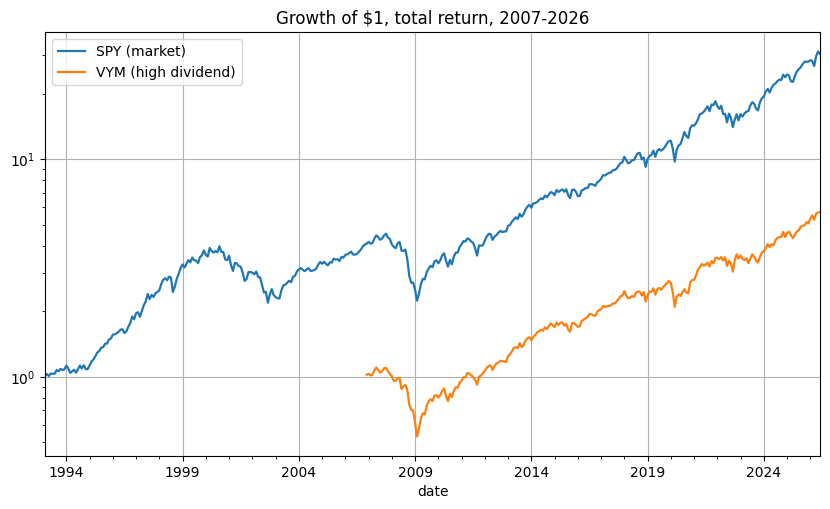

In [2]:
v,m=st.leg_summary(ret,'VYM'),st.leg_summary(ret,'SPY')
import pandas as pd
display(pd.DataFrame({'VYM (high div)':v,'SPY (market)':m}).T[['cagr','sharpe','vol_ann','max_drawdown']].round(3))
eqV=(1+ret['VYM'].dropna()).cumprod(); eqS=(1+ret['SPY'].dropna()).cumprod()
ax=eqS.plot(label='SPY (market)',lw=1.6); eqV.plot(ax=ax,label='VYM (high dividend)',lw=1.6)
ax.set_yscale('log'); ax.set_title('Growth of $1, total return, 2007-2026'); ax.legend(); plt.show()

## 4 · The teardown

The high-dividend line sits *below* the market — less wealth, lower Sharpe, no extra safety. The 'income' was never extra money.

In [3]:
s=st.spread_stats(sp); print(f"spread VYM-SPY: {s['mean_ann']:+.2%}/yr, Sharpe {s['sharpe']:.2f}, t {s['tstat']:.2f}, hit {s['hit_rate']:.0%}")

spread VYM-SPY: -1.54%/yr, Sharpe -0.26, t -1.13, hit 45%


**Read it plainly.** Higher yield bought lower total return. The dividend tilt is really a bet on banks, utilities and energy — the sectors that lagged the growth-led market.

## 5 · The verdict

**Signal: None** — high-div trailed on return and Sharpe. **Tradability: Mirage** — deeper drawdown too. **High-dividend tilt beats?: Busted.**

## 6 · Could you actually trade it?

You can buy VYM cheaply — but you'd own a value/sector tilt, not a premium, and you'd have trailed a plain index fund. If you want income from an index, sell a few shares: a 'home-made dividend' with no tilt and no story.

## 7 · Going further 🚪

Contrast with the *real* fundamental edges on the bench — [51 Blue-Chip](../../51-blue-chip/) (quality) and [52 Smoke-Screen](../../52-smoke-screen/) (accruals) — which point the right way, unlike the dividend tilt.